In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)

# Cargamos el modelo guardado
with open("../models/lightgbm_fraud.pkl", "rb") as f:
    modelo_final = pickle.load(f)

modelo = modelo_final["modelo"]
umbral = modelo_final["umbral"]

print(f"Modelo cargado correctamente")
print(f"Umbral: {umbral}")

Modelo cargado correctamente
Umbral: 0.8


In [2]:
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"X_test: {X_test.shape}")
print(f"Fraudes en test: {y_test.sum()}")

X_test: (56962, 30)
Fraudes en test: 98


In [3]:
# Predicciones con el umbral óptimo.
y_prob = modelo.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= umbral).astype(int)

print(f"Fraudes detectados: {y_pred.sum()}")
print(f"Fraudes reales: {y_test.sum()}")
print(f"Fraudes no detectados: {(y_test - y_pred).clip(0).sum()}")

Fraudes detectados: 99
Fraudes reales: 98
Fraudes no detectados: 15


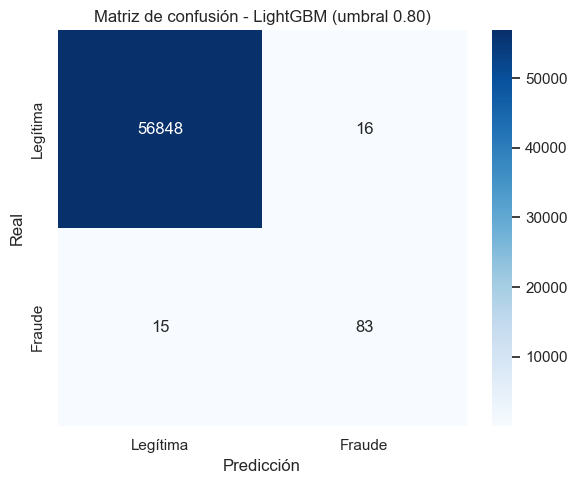

In [4]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legítima", "Fraude"],
            yticklabels=["Legítima", "Fraude"],
            ax=ax)

ax.set_title("Matriz de confusión - LightGBM (umbral 0.80)")
ax.set_xlabel("Predicción")
ax.set_ylabel("Real")

plt.tight_layout()
plt.savefig("../notebooks/images/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## Matriz de confusión — LightGBM (umbral 0.80)

|                  | Predicción Legítima | Predicción Fraude |
|---|---|---|
| **Real Legítima** | 56.848 (TN) ✅ | 16 (FP) ⚠️ |
| **Real Fraude**   | 15 (FN) ❌ | 83 (TP) ✅ |

### Interpretación

- **56.848 TN** — transacciones legítimas correctamente identificadas
- **16 FP** — legítimas marcadas como fraude (falsas alarmas) — muy pocas
- **83 TP** — fraudes correctamente detectados
- **15 FN** — fraudes que han pasado desapercibidos (los más peligrosos)

### Conclusión

De **98 fraudes reales**, el modelo detecta **83 (84.7% Recall)**.
Solo **15 fraudes** pasan desapercibidos.

Las falsas alarmas son únicamente **16 de 56.864** transacciones legítimas,
lo que supone un impacto mínimo para el banco.

> Un modelo en producción generaría una alerta por cada uno de los 99 casos
> marcados como fraude. El equipo de revisión solo tendría que revisar 16 casos
> que resultarían ser legítimos — un coste operativo muy asumible.

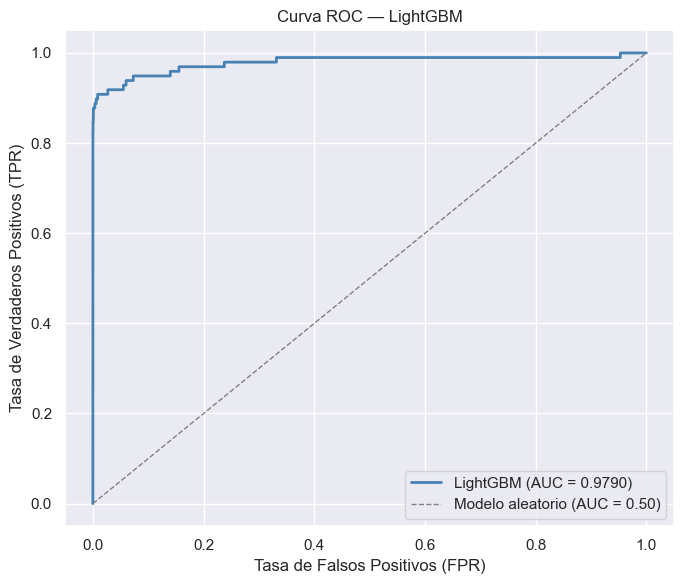

In [6]:
#Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color="steelblue", linewidth=2,
        label=f"LightGBM (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", linestyle="--",
        linewidth=1, label="Modelo aleatorio (AUC = 0.50)")

ax.set_title("Curva ROC — LightGBM")
ax.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax.legend()

plt.tight_layout()
plt.savefig("../notebooks/images/07_roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

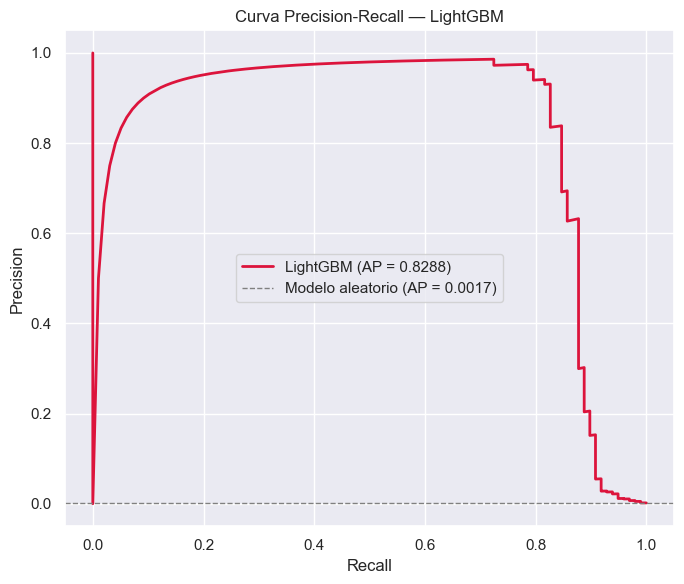

In [7]:
# Curva Precision-Recall
precision, recall, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(recall, precision, color="crimson", linewidth=2,
        label=f"LightGBM (AP = {ap:.4f})")
ax.axhline(y=y_test.mean(), color="gray", linestyle="--",
           linewidth=1, label=f"Modelo aleatorio (AP = {y_test.mean():.4f})")

ax.set_title("Curva Precision-Recall — LightGBM")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()

plt.tight_layout()
plt.savefig("../notebooks/images/08_precision_recall_curve.png", dpi=150, bbox_inches="tight")
plt.show()


## Curva ROC y Curva Precision-Recall — LightGBM

### Curva ROC (AUC = 0.9790)

| Métrica | Valor |
|---|---|
| AUC LightGBM | 0.9790 |
| AUC Modelo aleatorio | 0.5000 |

**Interpretación:**
- La curva sube casi verticalmente al principio — con muy pocas falsas alarmas
  ya detectamos el 90% de los fraudes.
- AUC de 0.9790 indica un modelo excelente, muy lejos del 0.50 aleatorio.

### Curva Precision-Recall (AP = 0.8288)

| Métrica | Valor |
|---|---|
| AP LightGBM | 0.8288 |
| AP Modelo aleatorio | 0.0017 |

**Interpretación:**
- Nuestro modelo es **487 veces mejor** que un modelo aleatorio en términos de AP.
- Hasta un Recall de ~0.75 la Precision se mantiene por encima de 0.95 —
  el modelo detecta el 75% de los fraudes con muy pocas falsas alarmas.
- A partir de Recall ~0.80 la Precision cae bruscamente — para detectar
  los últimos fraudes el modelo necesita generar más falsas alarmas.

> **¿Por qué la curva Precision-Recall es más informativa que la ROC
> en datasets desbalanceados?**
> La curva ROC puede ser engañosamente optimista porque incluye los TN
> (legítimas correctas). Con 99.83% de transacciones legítimas, tener
> pocos FP es fácil. La curva Precision-Recall ignora los TN y se centra
> exclusivamente en cómo el modelo maneja los fraudes.

### Conclusión

Nuestro umbral de **0.80** está situado justo antes de la caída brusca
de Precision — el punto óptimo donde maximizamos la detección de fraudes
sin disparar las falsas alarmas.
___

In [8]:
# Importancia de variables
importancias = pd.DataFrame({
    "variable": X_test.columns,
    "importancia": modelo.feature_importances_
}).sort_values("importancia", ascending=False)

print("Top 15 variables más importantes:")
print(importancias.head(15).to_string(index=False))

Top 15 variables más importantes:
variable  importancia
     V14          411
      V4          359
  Amount          333
     V12          256
      V3          248
     V17          240
     V26          239
      V7          236
      V1          227
     V13          205
    Time          194
     V16          188
     V18          187
      V8          187
     V21          185


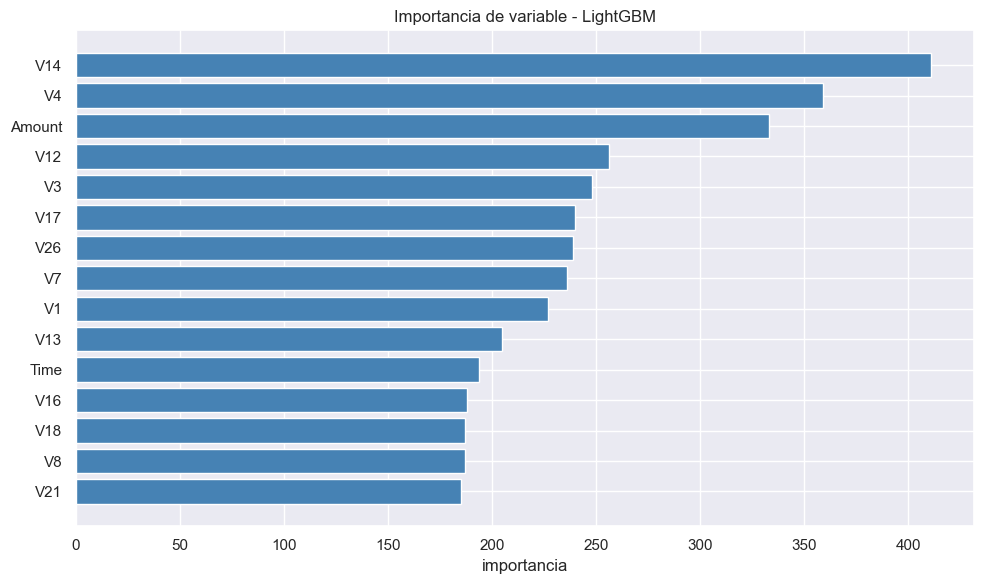

In [9]:
# Visualización
top15 = importancias.head(15)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(top15["variable"][::-1], top15["importancia"][::-1], color="steelblue")
ax.set_title("Importancia de variable - LightGBM")
ax.set_xlabel("importancia")

plt.tight_layout()
plt.savefig("../notebooks/images/09_importancia_variables.png", dpi=150, bbox_inches="tight")
plt.show()

## Importancia de variables — LightGBM

| Posición | Variable | Importancia |
|---|---|---|
| 1ª | V14 | 411 |
| 2ª | V4 | 359 |
| 3ª | Amount | 333 |
| 4ª | V12 | 256 |
| 5ª | V3 | 248 |
| 6ª | V17 | 240 |
| 7ª | V26 | 239 |
| 8ª | V7 | 236 |
| 9ª | V1 | 227 |
| 10ª | V13 | 205 |

### Análisis

**V14 — la variable más importante** con diferencia (411).
Coincide con el EDA donde tenía la segunda correlación más alta con fraude (-0.303).

**Amount en tercer lugar** — confirma el hallazgo del EDA. Los fraudes se
concentran en importes bajos y el modelo lo aprovecha intensamente.

**Time en undécimo lugar** — importancia moderada. El patrón horario
detectado en el EDA ayuda al modelo pero no es determinante.

**V4 en segundo lugar** — sorpresa respecto al EDA, donde tenía una
correlación moderada (0.133). El modelo le asigna mucho más peso del esperado.

### Conexión EDA → Modelo

| Variable | Correlación EDA | Importancia Modelo |
|---|---|---|
| V14 | -0.303 (2ª en EDA) | 411 (1ª en modelo) ✅ |
| V12 | -0.261 (3ª en EDA) | 256 (4ª en modelo) ✅ |
| V17 | -0.326 (1ª en EDA) | 240 (6ª en modelo) ⚠️ |
| Amount | moderada en EDA | 333 (3ª en modelo) ✅ |

> El EDA nos daba pistas sobre qué variables serían importantes
> y el modelo las ha confirmado en su mayoría. V17 es la única
> excepción notable — alta correlación lineal pero menor importancia
> en el modelo no lineal.

### Conclusión

El modelo utiliza una combinación de variables anonimizadas (V14, V4, V12)
y variables interpretables (Amount, Time) para detectar fraudes.
La coherencia entre el EDA y la importancia de variables confirma que
el proceso de análisis y modelado ha